In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [62]:
baseline = pd.read_csv("./baseline.csv")

In [63]:
coldplay = pd.read_csv("./coldplay.csv")

In [64]:
kidCudi = pd.read_csv("./kid_cudi.csv")

In [65]:
mattAndKim = pd.read_csv("./matt_and_kim.csv")

In [66]:
nested_list = [[1, 2, 3], [4, 5], [6]]
flattened_list = [item for sublist in nested_list for item in sublist]
print(flattened_list)

datasets = [
    baseline, mattAndKim,
]
upperLimits = [val.max() for dataset in datasets for val in [dataset.Bass, dataset.Mid, dataset.Treble]]
lowerLimits = [val.min() for dataset in datasets for val in [dataset.Bass, dataset.Mid, dataset.Treble]]


[1, 2, 3, 4, 5, 6]


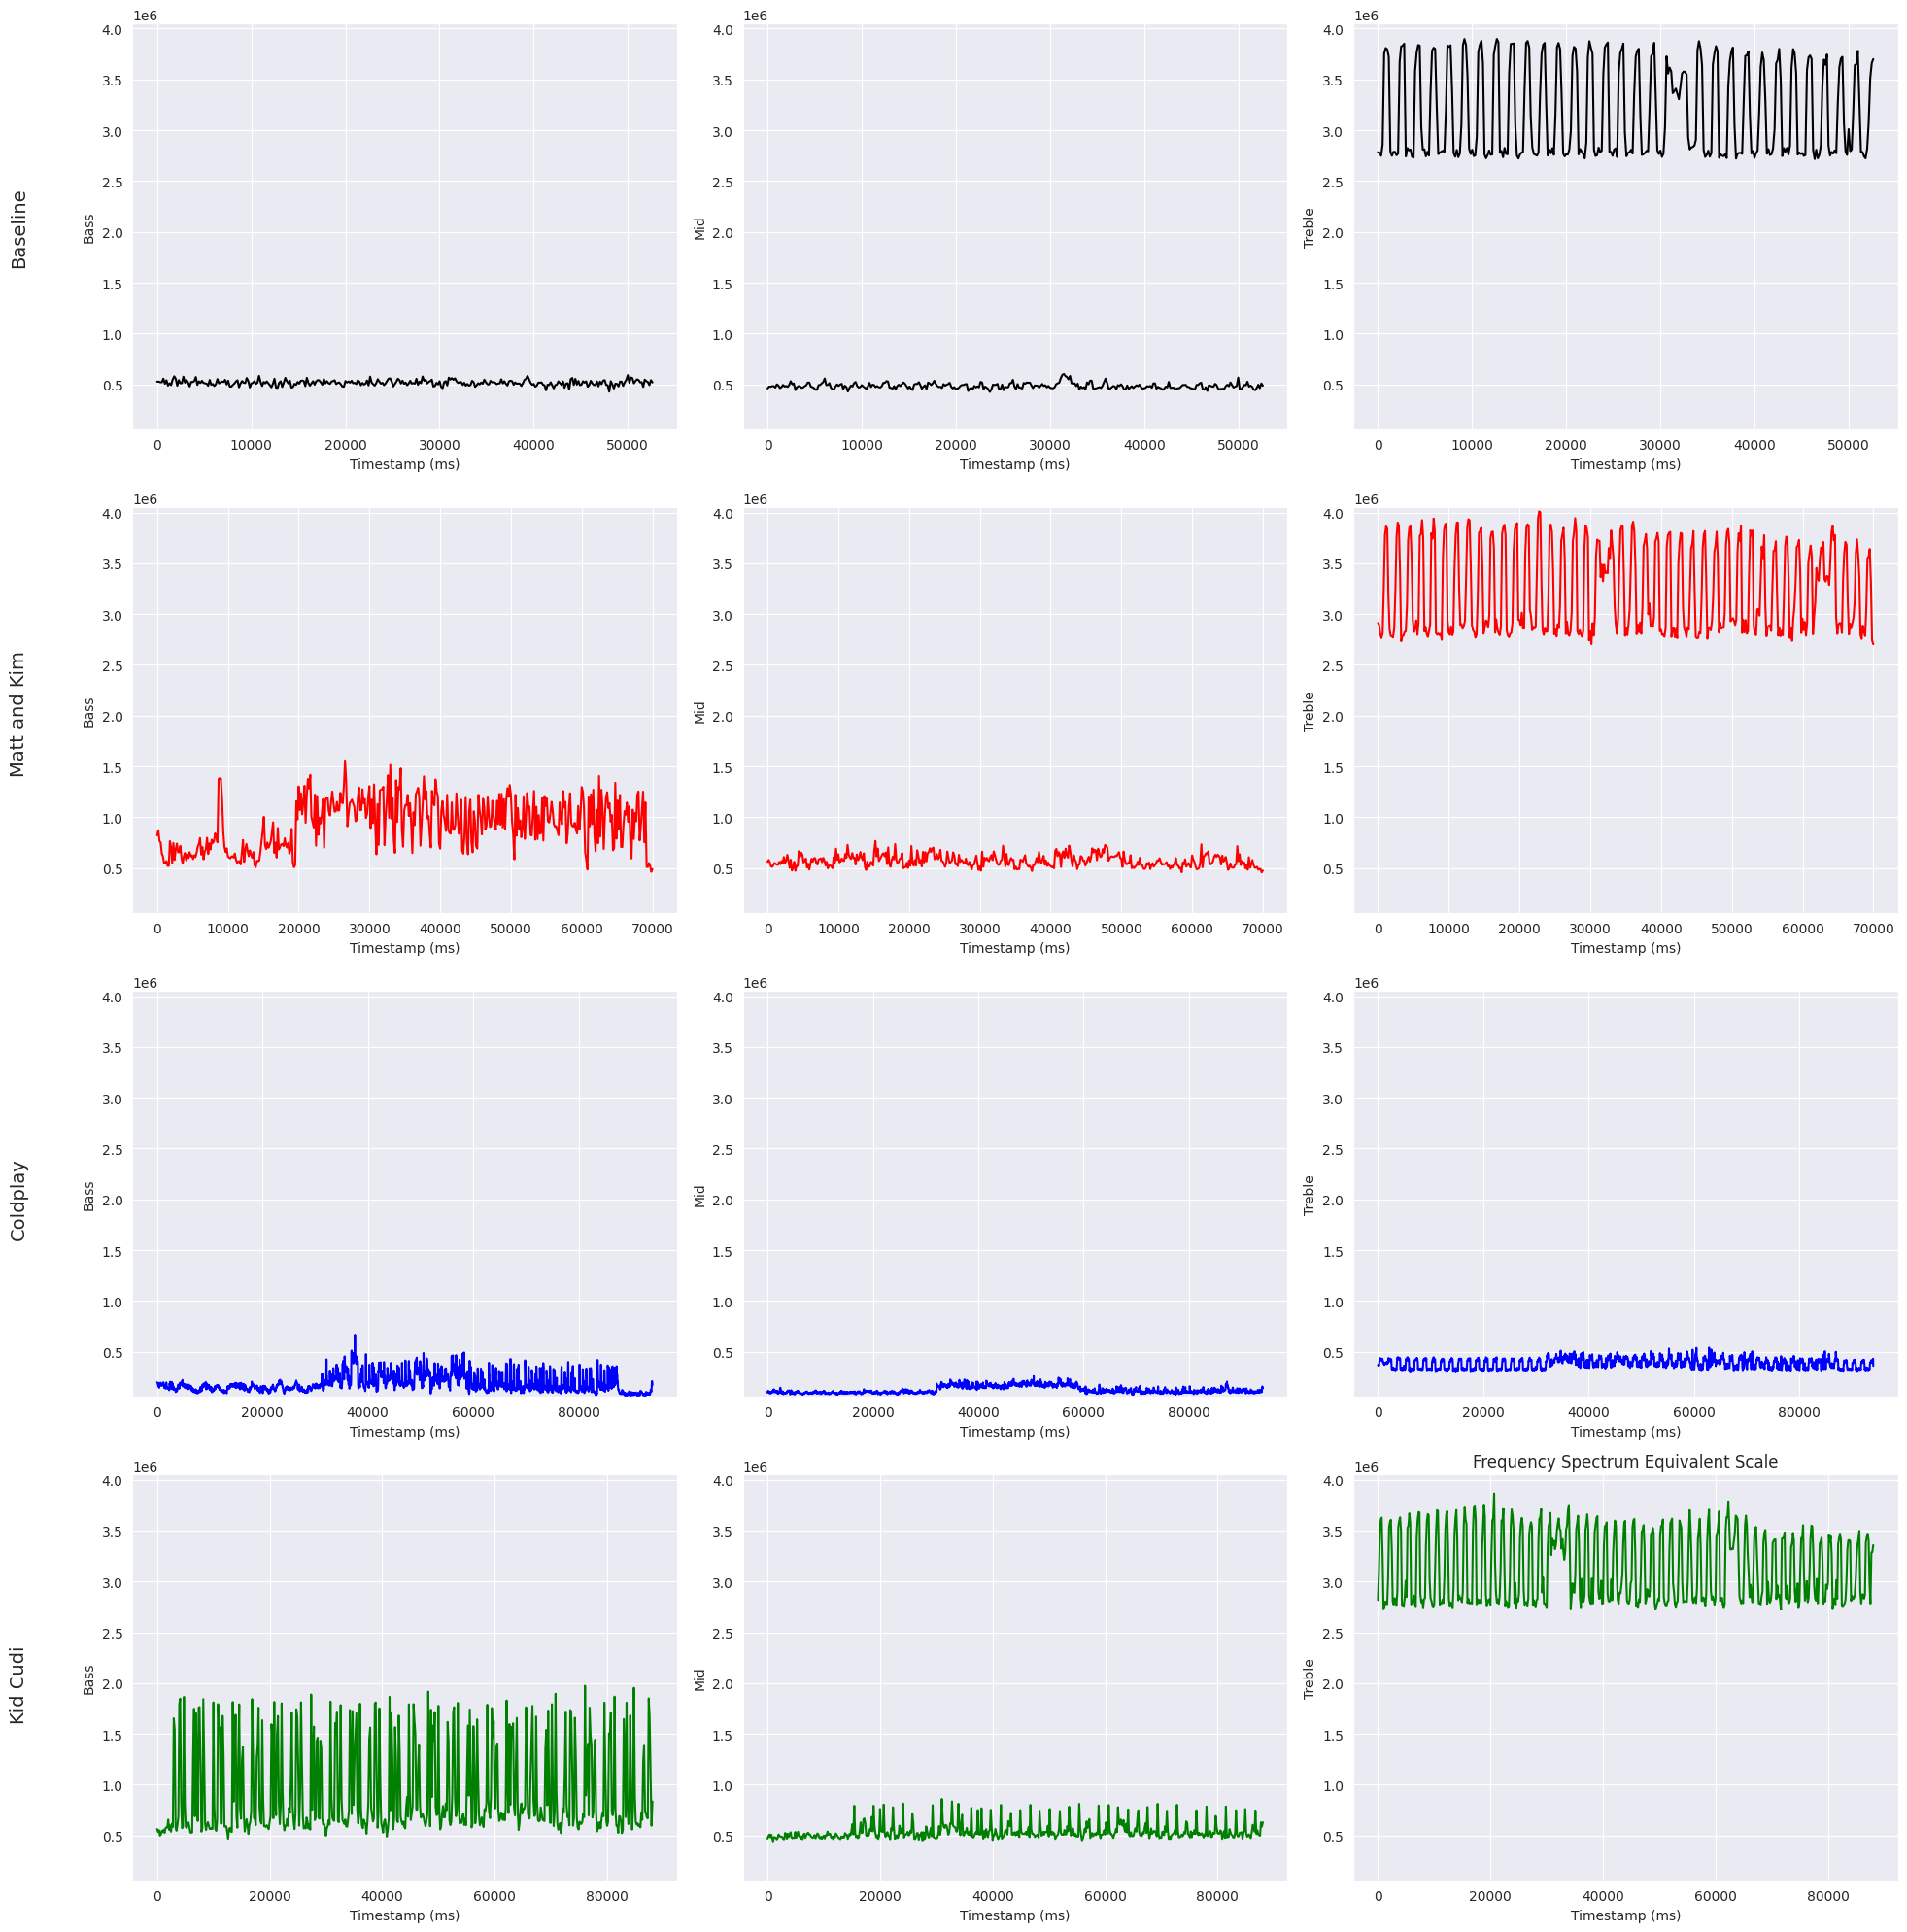

In [67]:

class DatasetDisplay:
    def __init__(self, title: str, dataset):
        self.title = title
        self.dataset = dataset

datasets = [
    DatasetDisplay("Baseline", baseline),
    DatasetDisplay("Matt and Kim", mattAndKim),
    DatasetDisplay("Coldplay", coldplay),
    DatasetDisplay("Kid Cudi", kidCudi),
]

fig, axs = plt.subplots(len(datasets),3, figsize=(20,5 * len(datasets)))

upperAmplitude = max([val.max() for d in datasets for val in [d.dataset.Bass, d.dataset.Mid, d.dataset.Treble]])
lowerAmplitude = min([val.min() for d in datasets for val in [d.dataset.Bass, d.dataset.Mid, d.dataset.Treble]])

def set_bounds(ax):
    ax.set_ylim(lowerAmplitude-lowerAmplitude * 0.01, upperAmplitude+upperAmplitude * 0.01)

def display_row(data, axs, color):
    ax = sns.lineplot(data, x="Timestamp (ms)", y="Bass", ax=axs[0], color=color)
    set_bounds(ax)

    ax = sns.lineplot(data, x="Timestamp (ms)", y="Mid", ax=axs[1], color=color)
    set_bounds(ax)

    ax = sns.lineplot(data, x="Timestamp (ms)", y="Treble", ax=axs[2], color=color)
    set_bounds(ax)

colors = ["black", "red", "blue", "green", "purple", "orange"]

for i in range(len(datasets)):
    plt.figtext(0.02, 0.13 + .25 * (len(datasets) - 1 - i), datasets[i].title, ha='left', va='center', fontsize=14, rotation=90)
    display_row(datasets[i].dataset, axs[i], colors[i % len(colors)])


plt.title("Frequency Spectrum Equivalent Scale")
plt.tight_layout(rect=[0.05, 0, 1, 1]) # Adjust layout to make space for row titles
plt.show()

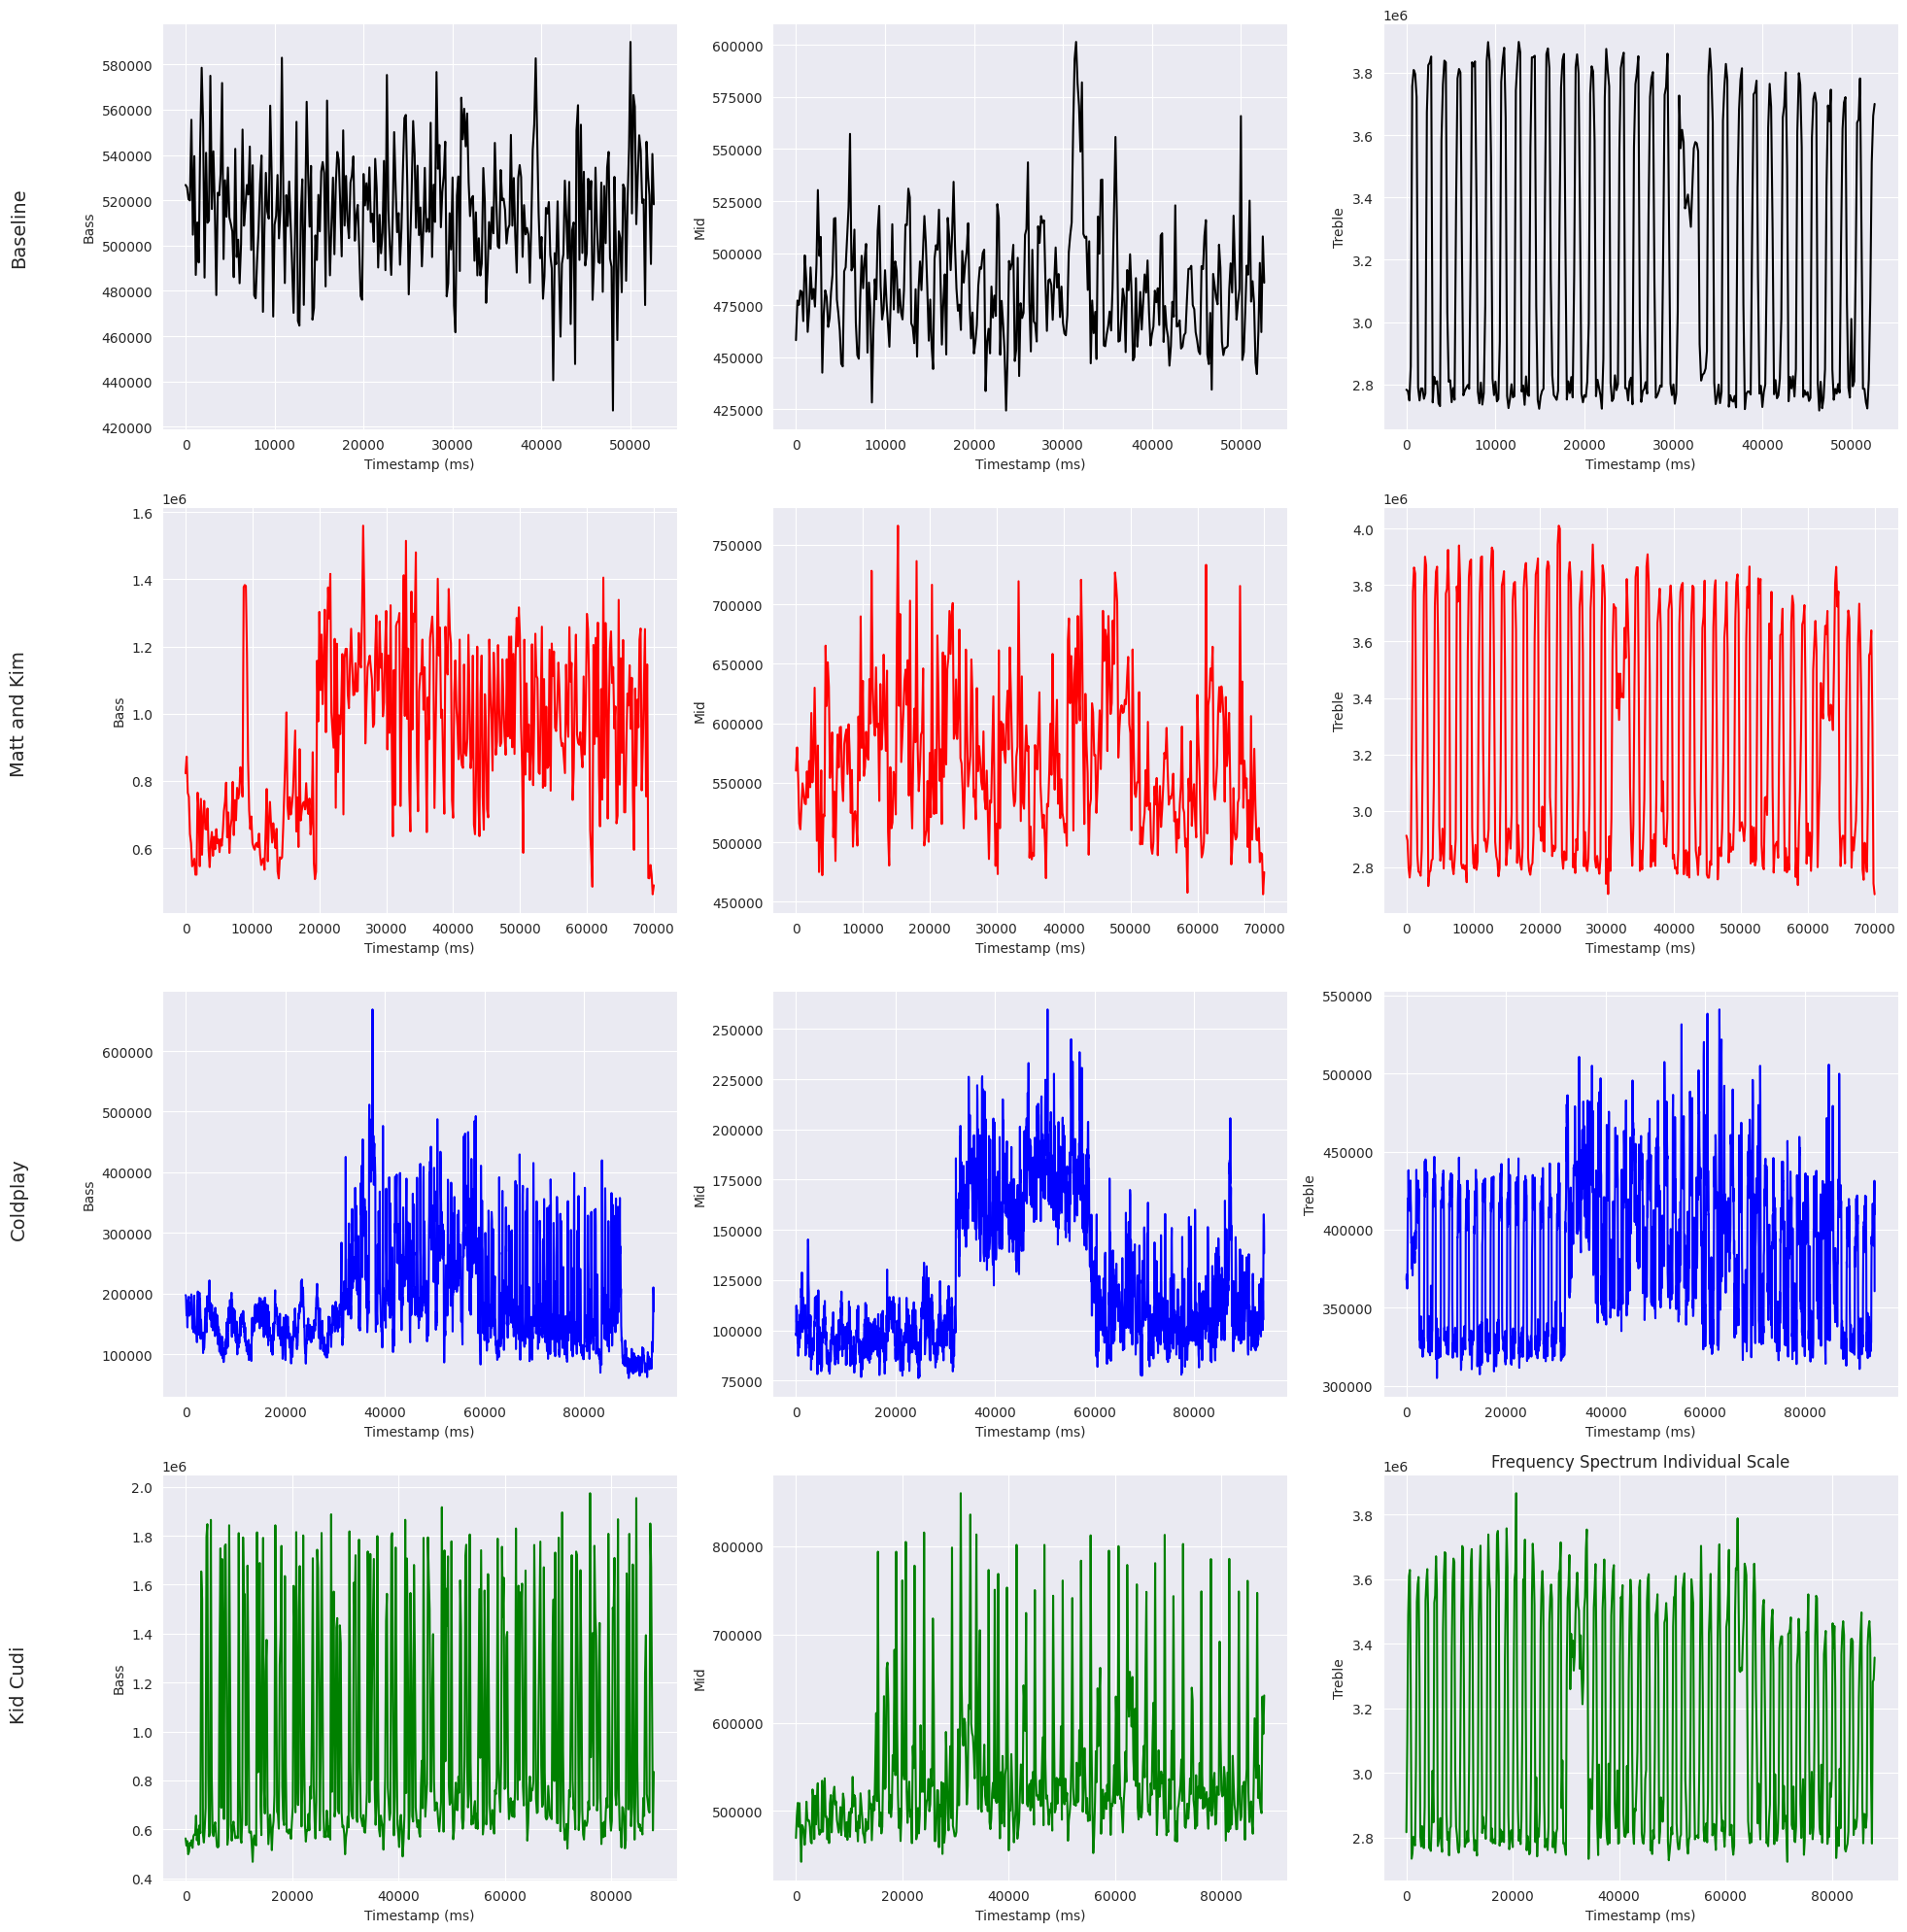

In [68]:

class DatasetDisplay:
    def __init__(self, title: str, dataset):
        self.title = title
        self.dataset = dataset

datasets = [
    DatasetDisplay("Baseline", baseline),
    DatasetDisplay("Matt and Kim", mattAndKim),
    DatasetDisplay("Coldplay", coldplay),
    DatasetDisplay("Kid Cudi", kidCudi),
]

fig, axs = plt.subplots(len(datasets),3, figsize=(20,5 * len(datasets)))

def display_row(data, axs, color):
    sns.lineplot(data, x="Timestamp (ms)", y="Bass", ax=axs[0], color=color)
    sns.lineplot(data, x="Timestamp (ms)", y="Mid", ax=axs[1], color=color)
    sns.lineplot(data, x="Timestamp (ms)", y="Treble", ax=axs[2], color=color)

colors = ["black", "red", "blue", "green", "purple", "orange"]

for i in range(len(datasets)):
    plt.figtext(0.02, 0.13 + .25 * (len(datasets) - 1 - i), datasets[i].title, ha='left', va='center', fontsize=14, rotation=90)
    display_row(datasets[i].dataset, axs[i], colors[i % len(colors)])


plt.title("Frequency Spectrum Individual Scale")
plt.tight_layout(rect=[0.05, 0, 1, 1]) # Adjust layout to make space for row titles
plt.show()